In [1]:
from pathlib import Path
import joblib

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from aeon.transformations.collection.feature_based import Catch22

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')

In [6]:
models_dir = data_dir / 'models'
models = {}
for file in models_dir.glob('c22*.pkl'):
    with open(file, 'rb') as infile:
        models[file.stem] = joblib.load(file)

In [7]:
c22_transformer = Catch22(features='all', catch24=True, use_pycatch22=True)
feature_names = c22_transformer.get_features_arguments
feature_names

['DN_HistogramMode_5',
 'DN_HistogramMode_10',
 'CO_f1ecac',
 'CO_FirstMin_ac',
 'CO_HistogramAMI_even_2_5',
 'CO_trev_1_num',
 'MD_hrv_classic_pnn40',
 'SB_BinaryStats_mean_longstretch1',
 'SB_TransitionMatrix_3ac_sumdiagcov',
 'PD_PeriodicityWang_th0_01',
 'CO_Embed2_Dist_tau_d_expfit_meandiff',
 'IN_AutoMutualInfoStats_40_gaussian_fmmi',
 'FC_LocalSimple_mean1_tauresrat',
 'DN_OutlierInclude_p_001_mdrmd',
 'DN_OutlierInclude_n_001_mdrmd',
 'SP_Summaries_welch_rect_area_5_1',
 'SB_BinaryStats_diff_longstretch0',
 'SB_MotifThree_quantile_hh',
 'SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1',
 'SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1',
 'SP_Summaries_welch_rect_centroid',
 'FC_LocalSimple_mean3_stderr',
 'Mean',
 'StandardDeviation']

In [8]:
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)

In [9]:
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

We use the C implementation of the catch 22 transformer in order to speed up the process.

We need this tranformed df to inspect features.

In [10]:
train_c22 = c22_transformer.fit_transform(train_X)
train_c22 = pd.DataFrame(train_c22, columns=feature_names)
train_c22.index = train.index
train_c22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr,Mean,StandardDeviation
id,,,,,,,,,,,,,,,,,,,,,
tt10855768,-0.333098,-0.569656,3.292878,9.0,0.231946,-0.049935,0.767677,8.0,0.062500,13.0,...,0.550,0.817875,12.0,1.717638,0.314286,0.314286,0.392699,0.585646,640039.02,7.702276e+05
tt3766354,-0.204680,-0.447203,5.038619,10.0,0.384456,-0.035084,0.676768,20.0,0.074074,13.0,...,0.480,0.855605,10.0,1.544890,0.171429,0.600000,0.147262,0.370692,1975049.87,2.726351e+06
tt6791096,-0.235415,-0.476199,4.240450,9.0,0.381551,-0.037754,0.535354,20.0,0.074074,13.0,...,0.475,0.845503,12.0,1.499035,0.171429,0.600000,0.196350,0.443455,947198.80,1.275064e+06
tt1821549,-0.968873,-0.759462,3.452775,8.0,0.382275,0.029799,0.787879,18.0,0.002604,14.0,...,-0.550,0.877449,7.0,1.670886,0.828571,0.742857,0.392699,0.713396,131952.38,8.603752e+04
tt7144666,-0.305268,-0.580867,5.878877,9.0,0.412512,-0.022879,0.676768,25.0,0.074074,14.0,...,0.555,0.843426,6.0,1.452820,0.171429,0.600000,0.098175,0.338991,1710723.00,1.823184e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tt7668870,-0.511009,-0.701741,4.263695,8.0,0.399966,0.106980,0.707071,13.0,0.080000,14.0,...,0.450,0.915131,10.0,1.543322,0.800000,0.828571,0.196350,0.632183,527703.77,5.610023e+05
tt8884430,-1.012251,-0.308258,3.125186,7.0,0.266802,-0.021545,0.777778,11.0,0.005540,14.0,...,-0.570,0.880690,9.0,1.690194,0.200000,0.514286,0.441786,0.766044,43593.67,2.696540e+04
tt9883996,-0.279530,-0.495243,5.479613,8.0,0.435485,-0.029595,0.424242,33.0,0.074074,15.0,...,0.490,0.892418,9.0,1.265352,0.400000,0.600000,0.049087,0.446650,55202.20,7.524475e+04


In [11]:
def plot_extreme_values(feature_name):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].plot(train_X[train_c22[feature_name].argmin()][0])
    feat_value = train_c22[feature_name].min()
    axs[0].set_title(f'{train.iloc[train_c22[feature_name].argmin()]['title']}: {feat_value:.2f}')


    axs[1].plot(train_X[train_c22[feature_name].argmax()][0])
    feat_value = train_c22[feature_name].max()
    axs[1].set_title(f'{train.iloc[train_c22[feature_name].argmax()]['title']}: {feat_value:.2f}')


    fig.suptitle(feature_name)

## Action

In [12]:
models['c22_action']

,estimator,Catch22Classi...ycatch22=True)
,scoring,'f1'
,response_method,'auto'
,thresholds,100
,cv,None
,refit,True
,n_jobs,None
,random_state,None
,store_cv_results,False
,n_estimators,200
,criterion,'gini'


Text(0, 0.5, '')

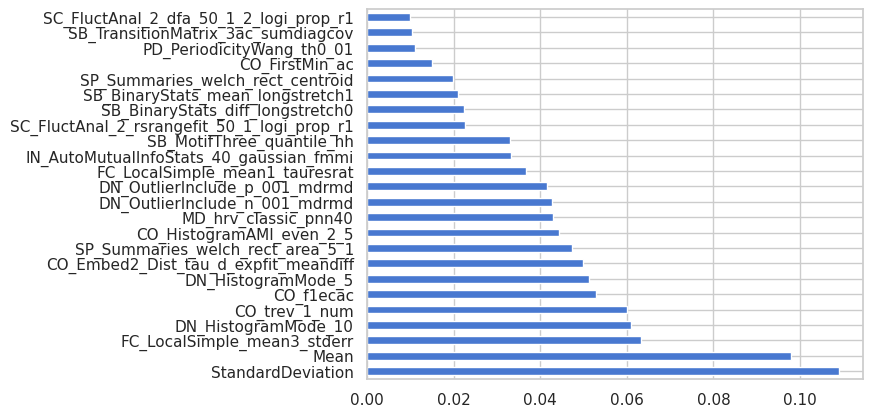

In [13]:
feat_importances = pd.DataFrame(zip(feature_names, models['c22_action'].estimator_.estimator_.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

Top two features are  standard deviation and mean, and we also have another feature regarding the level distribution in the top five features:
`DN_HistogramMode_10`, which returns the location of the bin with the most counts from a 10 binned histogram of the time series (time series with positively skewed distributions receive a negative score).

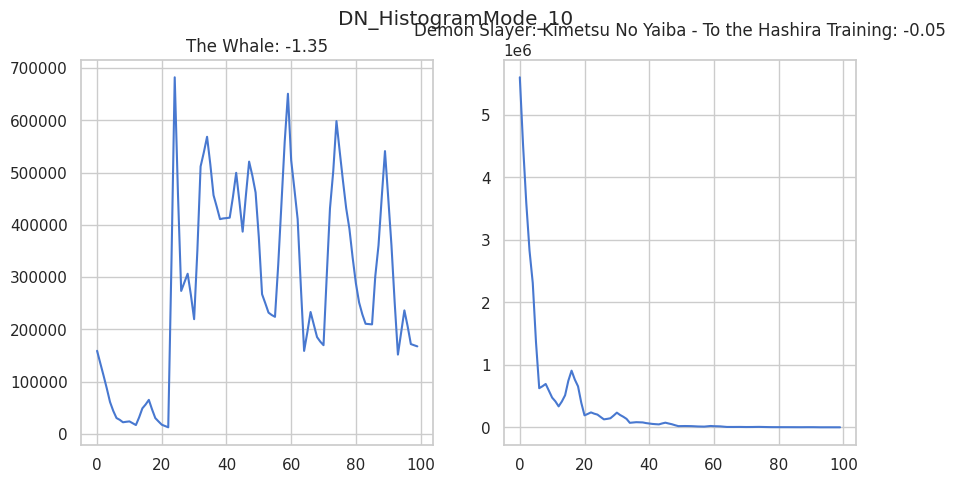

In [14]:
plot_extreme_values('DN_HistogramMode_10')

Other two features are:
- `CO_trev_1_num` is a non linear autocorrelation feature: it will be close to zero for time series for which the distribution of successive decreases in the time series matches the distribution of successive increases, but will be positive if increases tend to be larger in magnitude and negative if decreases tend to be larger in magnitude.

- `FC_LocalSimple_mean3_stderr` a 3-point mean forecasting is performed and standard deviation of the residuals is computed. It is higher when sampling rate is low with respect to the timescale of the dynamics variations.

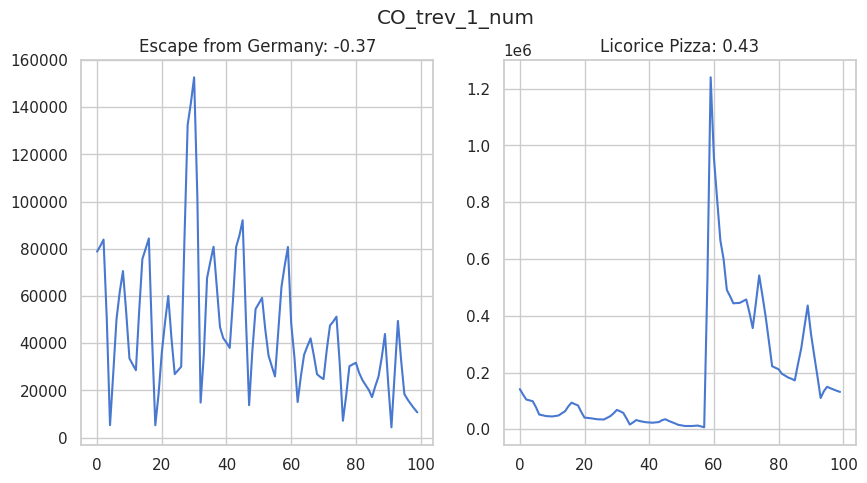

In [15]:
plot_extreme_values('CO_trev_1_num')

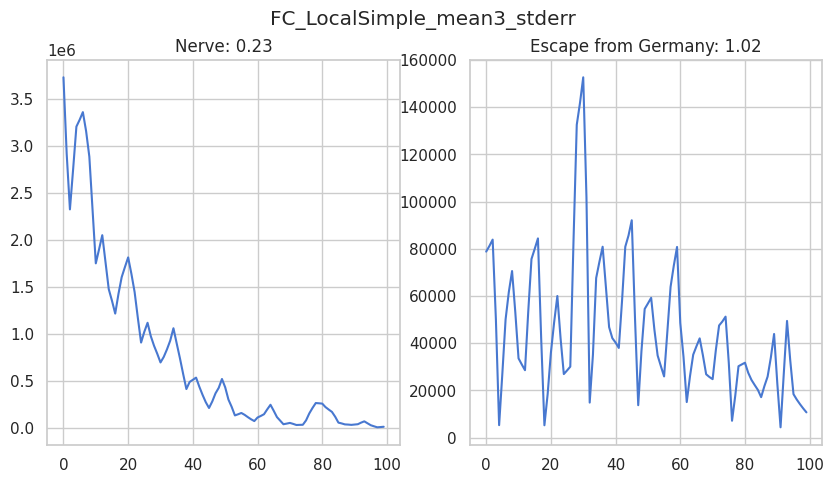

In [16]:
plot_extreme_values('FC_LocalSimple_mean3_stderr')

## Rating Category

In [17]:
models['c22_rating']

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,"RandomForestC...50, n_jobs=-1)"
,random_state,None
,n_jobs,1
,parallel_backend,None
,class_weight,None
,n_estimators,50


Text(0, 0.5, '')

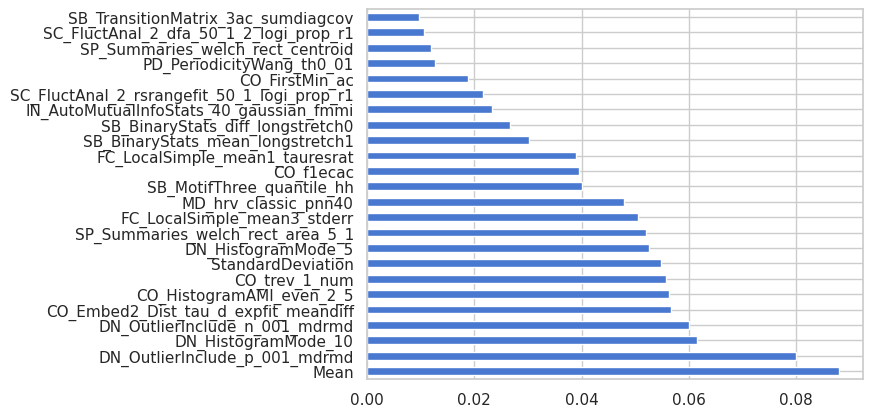

In [18]:
feat_importances = pd.DataFrame(zip(feature_names, models['c22_rating'].estimator_.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

For rating category top features include Mean and `DN_HistogramMode_10` and two features related to extreme event timing (positive and negative outliers): these features take values near to 0 when extreme events are approximatively equally likely to occurr anywhere on the time series, -1 when they occurr at the start of the time series and 1 when they occurr at the end.

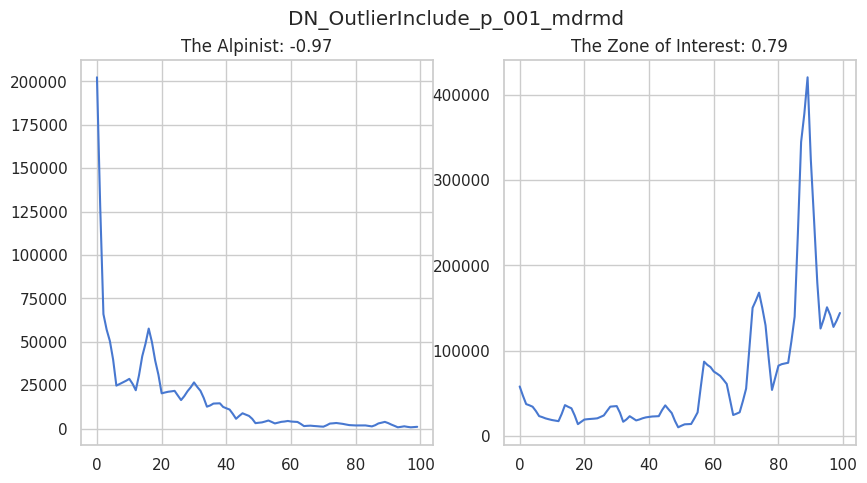

In [19]:
plot_extreme_values('DN_OutlierInclude_p_001_mdrmd')

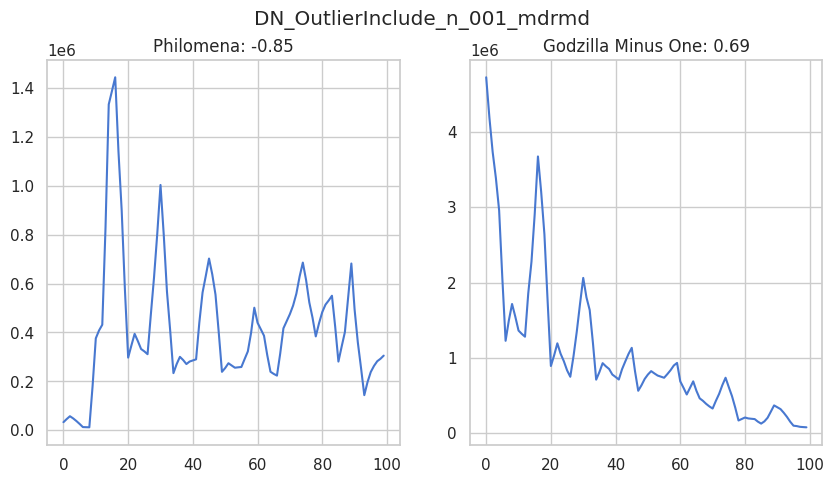

In [20]:
plot_extreme_values('DN_OutlierInclude_n_001_mdrmd')

## Rating (regression)

In [21]:
models['c22_regressor']

,features,'all'
,catch24,True
,outlier_norm,True
,replace_nans,True
,use_pycatch22,True
,estimator,"RandomForestR...00, n_jobs=-1)"
,random_state,None
,n_jobs,1
,parallel_backend,None
,n_estimators,200
,criterion,'squared_error'


Text(0, 0.5, '')

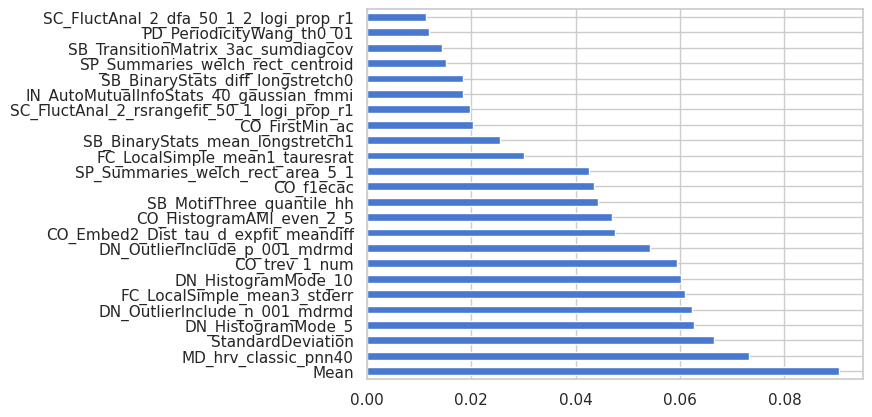

In [22]:
feat_importances = pd.DataFrame(zip(feature_names, models['c22_regressor']._estimator.feature_importances_)).set_index(0)
feat_importances.sort_values(1, ascending=False).plot.barh(legend=False)
plt.ylabel('')

In addition to mean, standard deviation and histogram mode, we have again a feature related to the timing of negative outliers and a feature that records the proportion of high incremental changes in the series.

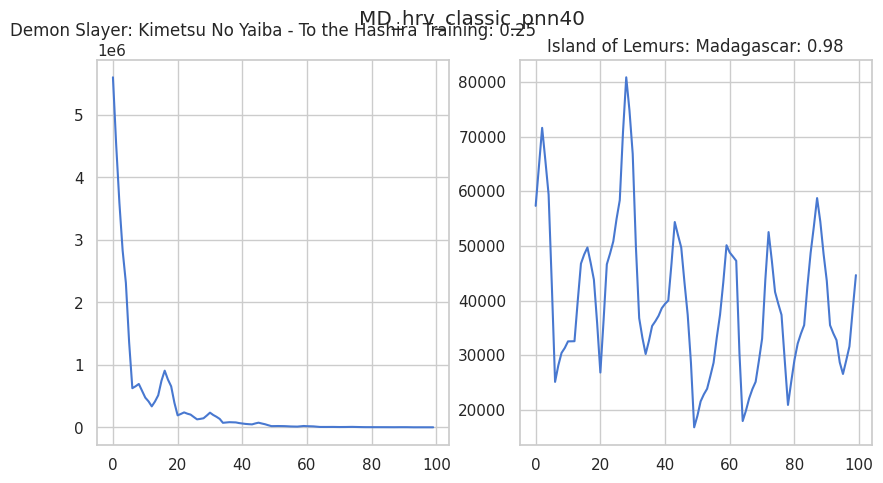

In [23]:
plot_extreme_values('MD_hrv_classic_pnn40')

Overall, time independent features like mean standard deviation and skew of the time series were important features for all tasks, but also time dependent features, especially regarding the timing of extreme events and differencing of the time series emerged.